# Vizualizacije

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score, accuracy_score
import xgboost as xgb
from xgboost import XGBClassifier

from theme import *

In [ ]:
Path("../plots/visualizations").mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/trees10.csv")
print(f"{df.shape[0]} stabala, {df.shape[1]} kolona")

16978 stabala, 91 kolona


In [3]:
TARGETS = {
    "which_algo", "which_better", "ab_correct", "mcts_correct", "mcts_correct_rate",
    "is_contested", "margin_category", "delta", "ab_regret", "mcts_regret",
}

BEHAVIORAL = {
    "ab_nodes_visited", "ab_pruning_rate", "ab_root_eval_std",
    "ab_instability", "ab_depth_reached", "ab_ranking_correlation",
    "mcts_visit_entropy", "mcts_vote_margin", "mcts_best_value_estimate",
    "exact_best_value", "exact_second_best_value",
    "best_move_margin", "best_move_margin_normalized",
}

num_cols = set(df.select_dtypes("number").columns)
feat_B = sorted(num_cols - TARGETS - BEHAVIORAL, key=list(df.columns).index)
feat_B = [c for c in feat_B if df[c].std() > 0]

le = LabelEncoder()
y_algo = le.fit_transform(df["which_algo"])
label_names = list(le.classes_)

le_better = LabelEncoder()
y_better = le_better.fit_transform(df["which_better"])
better_labels = list(le_better.classes_)

df["bf_bin"] = df["branching_factor"]  
df["cd_bin"] = pd.cut(df["chance_node_density"], [-0.01, 0.001, 0.2, 0.4, 0.6, 0.8, 1.01],
                      labels=["0.0", "0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"])

X_B = df[feat_B].values
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 1. Dijagram faza: koji algoritam pobedjuje?

Ilustrujemo u koji delovi prostora pogoduju kojem algoritmu kroz dve glavne ose `ab_reach_depth` i gustinom CHANCE čvorova `cd`. CHANCE čvorovi otežavaju učinak AB dok nam `ab_reach_depth` govori o budžetu koji algoritam ima.

In [4]:
rd_bins = pd.qcut(df["ab_reach_depth"], 6, precision=1)
df["rd_bin"] = rd_bins.cat.rename_categories(lambda iv: f"{iv.left:.1f}-{iv.right:.1f}")

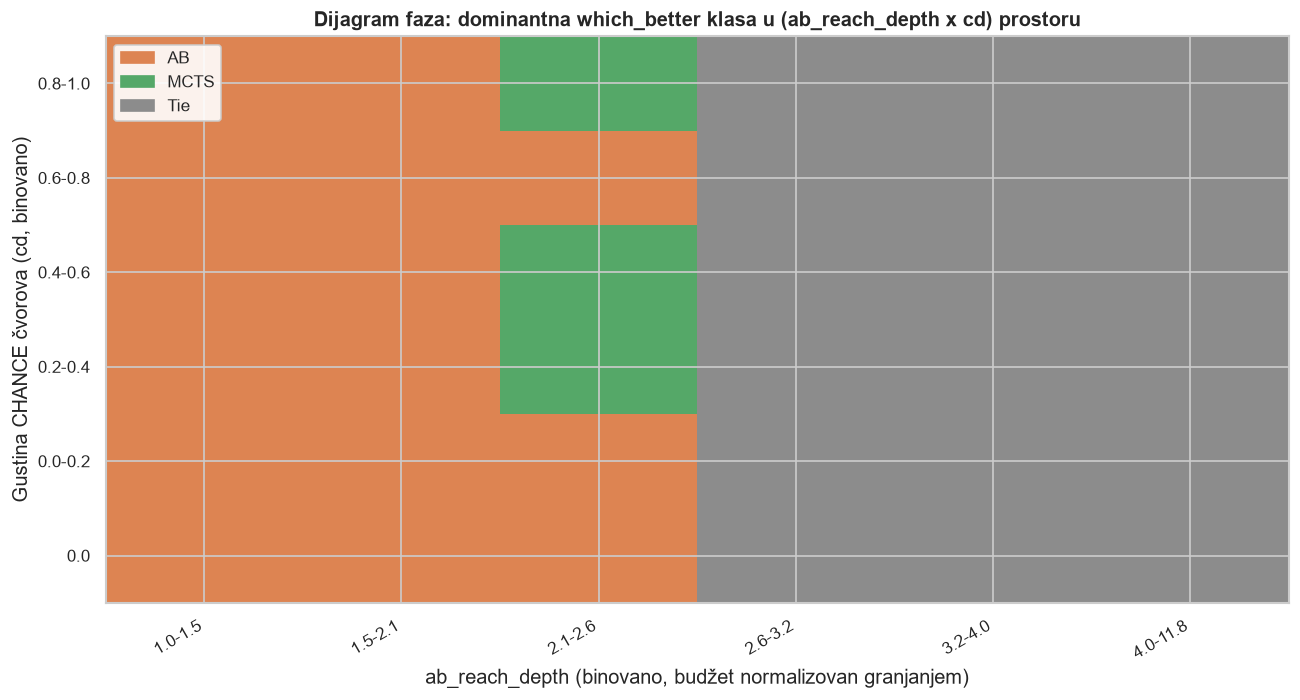

In [5]:
klase_int = {c: i for i, c in enumerate(BETTER_ORDER)}
cmap3 = ListedColormap([BETTER_COLORS[c] for c in BETTER_ORDER])
norm3 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap3.N)

dominantna = df.groupby(["cd_bin", "rd_bin"], observed=True)["which_better"].agg(
    lambda x: x.mode()[0]
)
pivot = dominantna.unstack("rd_bin")
pivot_int = pivot.sort_index(ascending=False).apply(lambda col: col.map(klase_int))

fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(pivot_int.values, cmap=cmap3, norm=norm3, aspect="auto", interpolation="nearest")

ax.set_xticks(range(len(pivot_int.columns)))
ax.set_xticklabels(pivot_int.columns, fontsize=10, rotation=30, ha="right")
ax.set_yticks(range(len(pivot_int.index)))
ax.set_yticklabels(pivot_int.index, fontsize=10)
ax.set_xlabel("ab_reach_depth (binovano, budžet normalizovan granjanjem)", fontsize=12)
ax.set_ylabel("Gustina CHANCE čvorova (cd, binovano)", fontsize=12)
ax.set_title("Dijagram faza: dominantna which_better klasa u (ab_reach_depth x cd) prostoru",
             fontsize=12, fontweight="bold")

legend_patches = [Patch(color=BETTER_COLORS[c], label=c) for c in BETTER_ORDER]
ax.legend(handles=legend_patches, loc="upper left", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

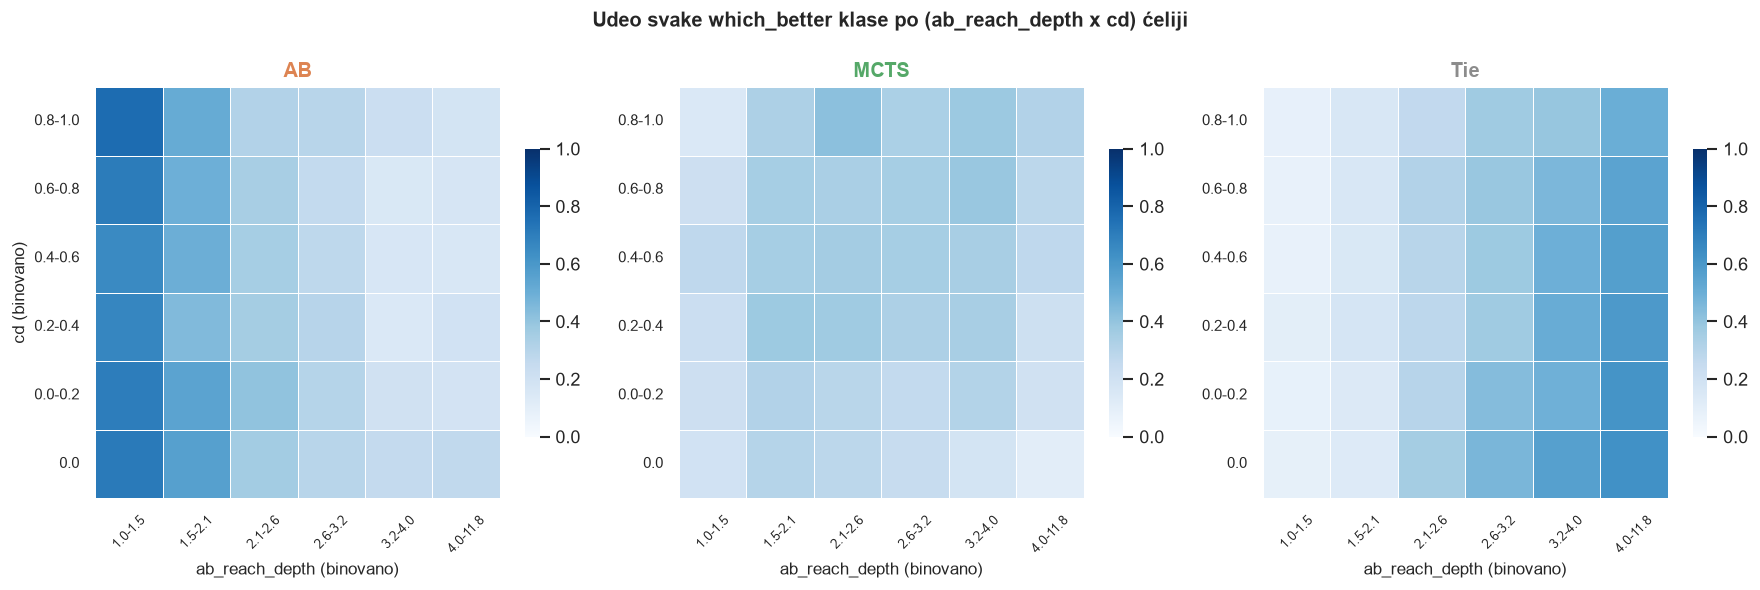

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, klasa) in enumerate(zip(axes, BETTER_ORDER)):
    frakcija = (
        (df["which_better"] == klasa)
        .groupby([df["cd_bin"], df["rd_bin"]], observed=True)
        .mean()
        .unstack("rd_bin")
        .sort_index(ascending=False)
    )
    sns.heatmap(
        frakcija, ax=ax, cmap="Blues", vmin=0, vmax=1,
        linewidths=0.3, linecolor="white", cbar_kws={"shrink": 0.7}
    )
    ax.set_title(klasa, fontweight="bold", color=BETTER_COLORS[klasa], fontsize=12)
    ax.set_xlabel("ab_reach_depth (binovano)", fontsize=10)
    ax.set_ylabel("cd (binovano)" if i == 0 else "", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.suptitle("Udeo svake which_better klase po (ab_reach_depth x cd) ćeliji",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

AB dominira ceo nisko budžetni deo bez obzira na cd jer MCTS sa malim brojem poseta po grani ne stigne da izgradi pouzdanu statistiku, dok Tie dominira ceo visoko budžetni opseg jer oba algoritma tada uglavnom nađu isti (ili blizak) potez. MCTS izranja kao srednja traka, najizraženija baš na višem cd, gde CHANCE usrednjavanje otežava AB-ovu plitku heurističku procenu više nego MCTS-ovo uzorkovanje. 

## 2. AB i MCTS tačnost

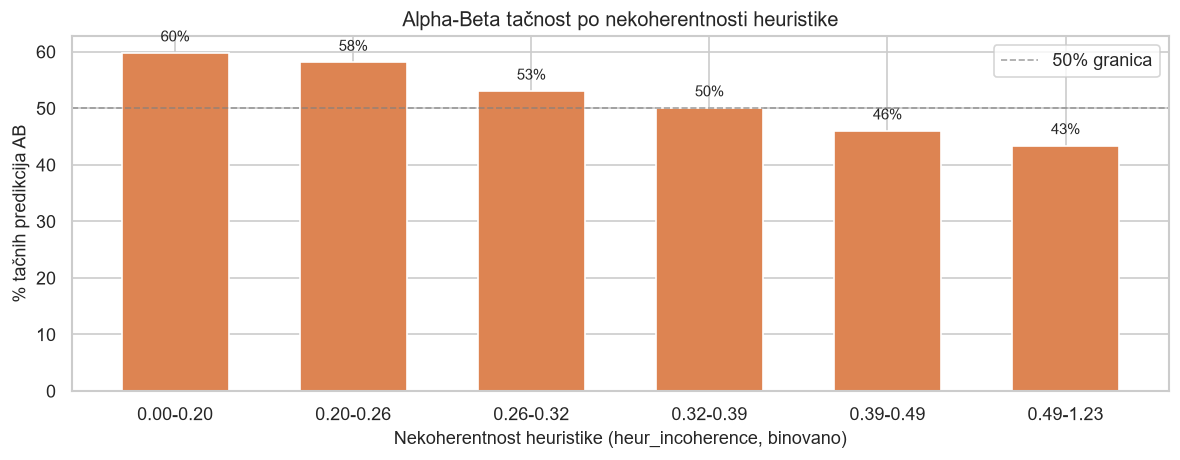

In [7]:
hi_bins = pd.qcut(df["heur_incoherence"], 6, precision=2)
df["hi_bin"] = hi_bins.cat.rename_categories(lambda iv: f"{iv.left:.2f}-{iv.right:.2f}")

ab_po_hi = df.groupby("hi_bin", observed=True)["ab_correct"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    [str(v) for v in ab_po_hi.index],
    ab_po_hi.values,
    color=CLASS_COLORS["AB"], edgecolor="white", width=0.6
)
ax.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="50% granica")
ax.set_xlabel("Nekoherentnost heuristike (heur_incoherence, binovano)", fontsize=11)
ax.set_ylabel("% tačnih predikcija AB", fontsize=11)
ax.set_title("Alpha-Beta tačnost po nekoherentnosti heuristike", fontsize=12)
for bar, val in zip(bars, ab_po_hi.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

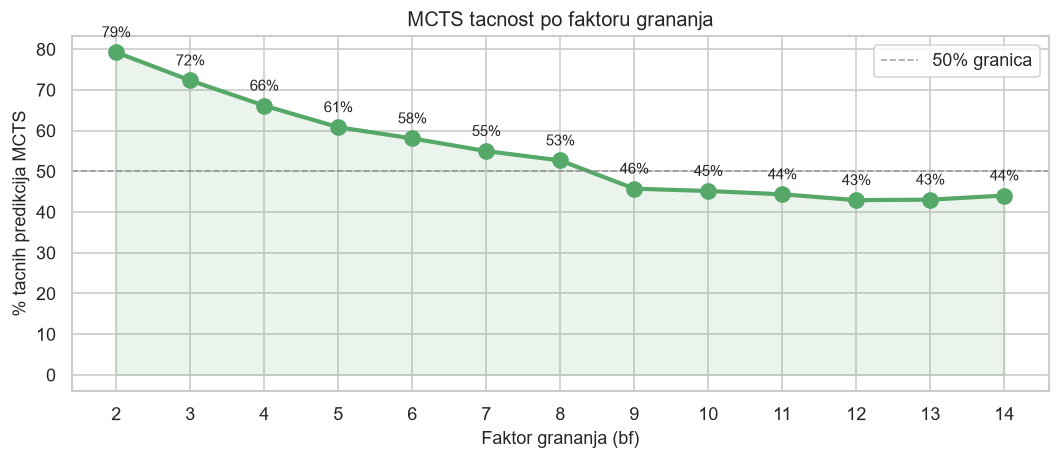

In [8]:
mcts_po_bf = df.groupby("branching_factor")["mcts_correct"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mcts_po_bf.index, mcts_po_bf.values, "o-",
        color=CLASS_COLORS["MCTS"], linewidth=2.5, markersize=9)
ax.fill_between(mcts_po_bf.index, mcts_po_bf.values, alpha=0.12, color=CLASS_COLORS["MCTS"])
ax.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="50% granica")
ax.set_xlabel("Faktor grananja (bf)", fontsize=11)
ax.set_ylabel("% tacnih predikcija MCTS", fontsize=11)
ax.set_title("MCTS tacnost po faktoru grananja", fontsize=12)
ax.set_xticks(mcts_po_bf.index)
for x, y in zip(mcts_po_bf.index, mcts_po_bf.values):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

AB-ova tačnost opada glatko i monotono sa porastom heur_incoherence. MCTS-ova tačnost, opada oštro i skoro monotono sa porastom faktora grananja što je direktna posledica budžeta podeljenog na sve veći broj grana, isti budžet mora da pokrije sve više mogućih poteza, pa se statistika po grani pogoršava i MCTS-ova odluka postaje sve manje pouzdana.

## 3. Preciznost rangiranja AB algoritma

Binarna metrika `ab_correct` razlikuje samo dve situacije: tacan i pogresan izbor.
Medjutim, algoritam koji bira drugi po kvalitetu potez se razlikuje
od algoritma koji bira najlosiji, a oba dobijaju isti binarni rezultat 0.

Spirmanova korelacija rangova (`ab_ranking_correlation`) meri koliko tacno AB
uredjuje poteze iz korena. Vrednost +1 je savrseno uredjivanje, -1 obrnuto.


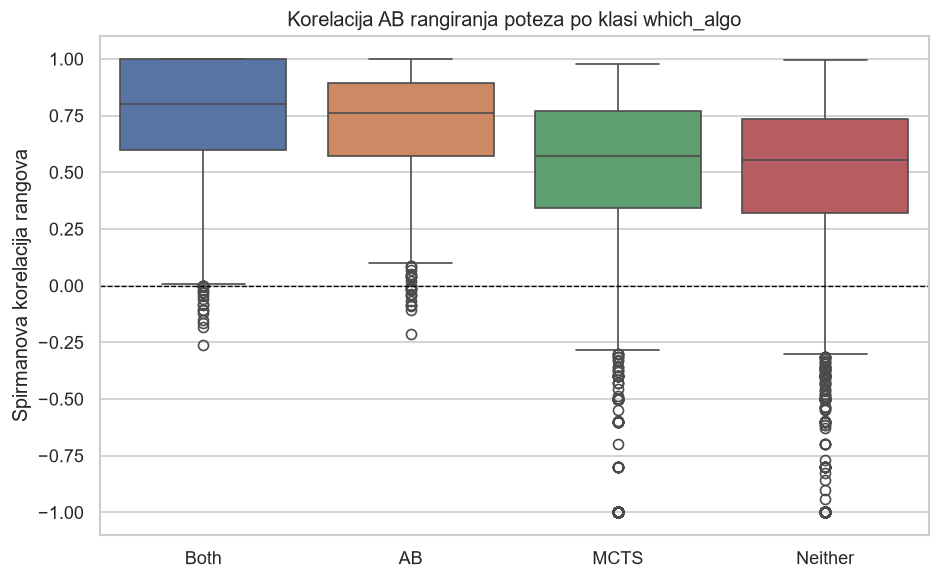

Srednja Spirmanova korelacija po klasi:
which_algo
Both       0.759
AB         0.714
MCTS       0.457
Neither    0.469
Name: ab_ranking_correlation, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="which_algo", y="ab_ranking_correlation",
    hue="which_algo", order=CLASS_ORDER, palette=CLASS_COLORS, legend=False,
    ax=ax
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("")
ax.set_ylabel("Spirmanova korelacija rangova")
ax.set_title("Korelacija AB rangiranja poteza po klasi which_algo")

plt.tight_layout()
plt.savefig("../plots/visualizations/03_ab_ranking.png", dpi=120)
plt.show()

print("Srednja Spirmanova korelacija po klasi:")
print(df.groupby("which_algo")["ab_ranking_correlation"].mean().reindex(CLASS_ORDER).round(3))

## 4. Generalizacija: predikcija iz same strukture stabla (feat_B)

Test je stroži od obične kros-validacije: treniramo bez bf=7, testiramo na **bf=7**
(interpolacija vrednost unutar viđenog opsega). Zatim treniramo bez bf=14 i
testiramo na **bf=14** (ekstrapolacija van vrednosti u skupu, `bf_range=(2,14)`).

In [10]:
# referentna tacnost: 5-fold cross-val na celom skupu, oba glavna cilja
rf_ref = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
ref_scores = cross_val_score(rf_ref, X_B, y_algo, cv=cv5, scoring="f1_macro")
ref_f1 = ref_scores.mean()
print(f"Referenca which_algo   (5-fold CV, feat_B): macro-F1 = {ref_f1:.3f} +/- {ref_scores.std():.3f}")

rf_ref2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
ref_scores_better = cross_val_score(rf_ref2, X_B, y_better, cv=cv5, scoring="f1_macro")
ref_f1_better = ref_scores_better.mean()
print(f"Referenca which_better (5-fold CV, feat_B): macro-F1 = {ref_f1_better:.3f} +/- {ref_scores_better.std():.3f}")

Referenca which_algo   (5-fold CV, feat_B): macro-F1 = 0.402 +/- 0.005


Referenca which_better (5-fold CV, feat_B): macro-F1 = 0.559 +/- 0.008


In [11]:
targets = {
    "which_algo":   (y_algo, label_names, "macro"),
    "which_better": (y_better, better_labels, "macro"),
    "ab_correct":   (df["ab_correct"].values, ["Pogresan", "Tacan"], "binary"),
    "mcts_correct": (df["mcts_correct"].values, ["Pogresan", "Tacan"], "binary"),
}

scenarios = [
    ("bf=7 (interpolacija)",    df["branching_factor"] == 7),
    ("bf=14 (ekstrapolacija)",  df["branching_factor"] == 14),
    ("bf=7 i bf=14 (oba)",      df["branching_factor"].isin([7, 14])),
]

all_results = []
for scenario_name, test_mask in scenarios:
    train_mask = ~test_mask
    for target_name, (y_full, disp_labels, avg) in targets.items():
        rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        rf.fit(X_B[train_mask], y_full[train_mask])
        y_pred = rf.predict(X_B[test_mask])

        acc = accuracy_score(y_full[test_mask], y_pred)
        f1  = f1_score(y_full[test_mask], y_pred, average=avg)
        all_results.append({
            "Scenario": scenario_name,
            "Cilj": target_name,
            "Tacnost": round(acc, 3),
            "F1": round(f1, 3),
            "N test": int(test_mask.sum()),
        })

results_df = pd.DataFrame(all_results)
results_df.pivot(index="Scenario", columns="Cilj", values=["Tacnost", "F1"])

Tacnost                                       \
Cilj                   ab_correct mcts_correct which_algo which_better   
Scenario                                                                 
bf=14 (ekstrapolacija)      0.667        0.722      0.548        0.622   
bf=7 (interpolacija)        0.658        0.687      0.487        0.569   
bf=7 i bf=14 (oba)          0.653        0.704      0.506        0.590   

                               F1                                       
Cilj                   ab_correct mcts_correct which_algo which_better  
Scenario                                                                
bf=14 (ekstrapolacija)      0.574        0.662      0.481        0.610  
bf=7 (interpolacija)        0.674        0.735      0.360        0.538  
bf=7 i bf=14 (oba)          0.637        0.717      0.400        0.567

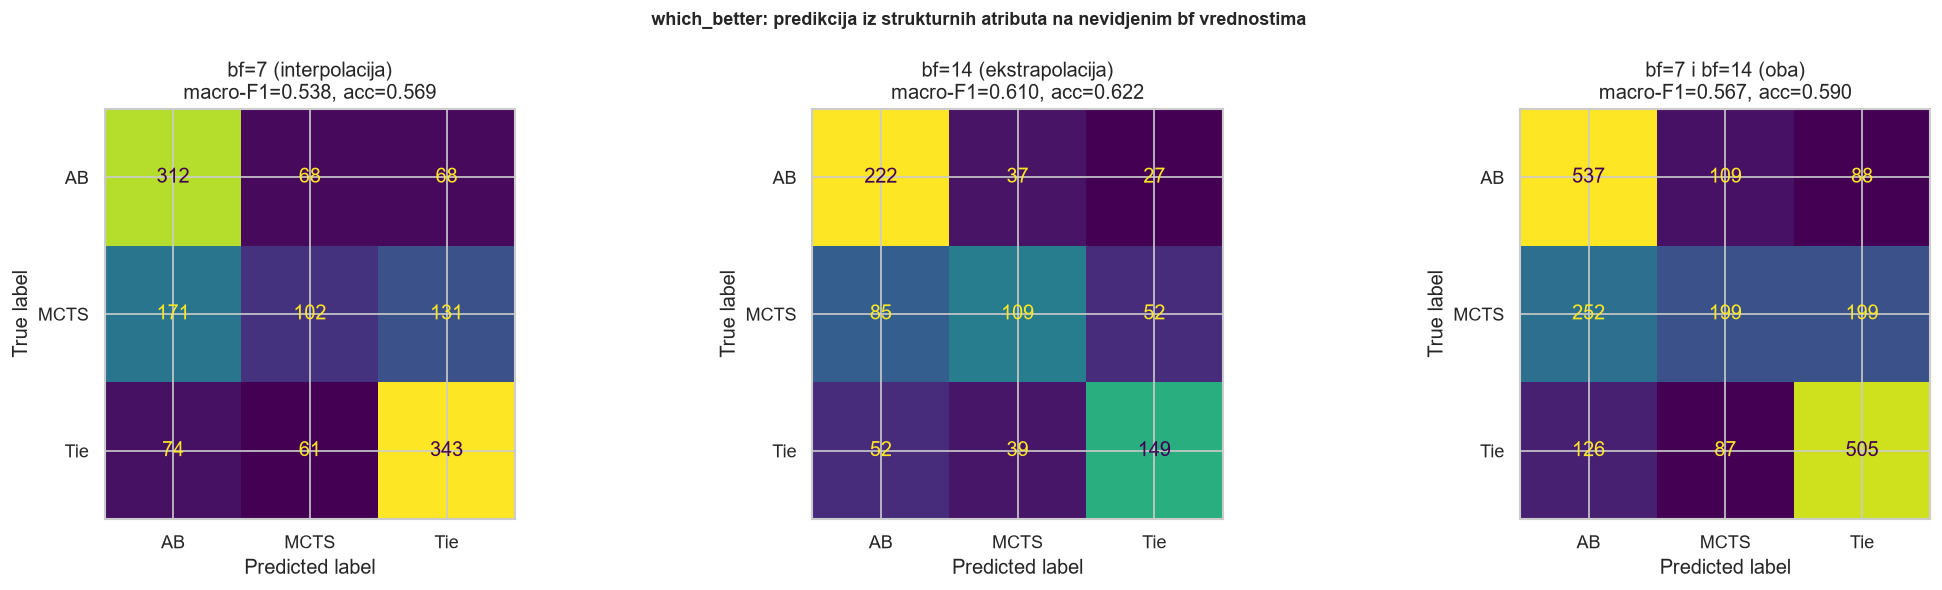

In [ ]:
fig, axes = plt.subplots(1, len(scenarios), figsize=(18, 5))

for ax, (name, test_mask) in zip(axes, scenarios):
    train_mask = ~test_mask
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_B[train_mask], y_better[train_mask])
    y_pred = rf.predict(X_B[test_mask])

    f1  = f1_score(y_better[test_mask], y_pred, average="macro")
    acc = accuracy_score(y_better[test_mask], y_pred)
    ConfusionMatrixDisplay.from_predictions(
        y_better[test_mask], y_pred,
        display_labels=better_labels,
        ax=ax, colorbar=False
    )
    ax.set_title(f"{name}\nmacro-F1={f1:.3f}, acc={acc:.3f}")

plt.suptitle("which_better: predikcija iz strukturnih atributa na nevidjenim bf vrednostima",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/visualizations/04b_generalization_cm_better.png", dpi=120)
plt.show()

## 6. Sta čini stablo teskim?

Klasa Neither sadrzi stabla na kojima ni AB ni MCTS ne mogu da nađu optimalan potez.
Razumevanje strukturnih karakteristika ovih stabala ima prakticnu vrednost:
ako mozemo prepoznati "teško" stablo pre pokretanja pretrage, mozemo prilagoditi
strategiju, povecati budzet, koristiti hibridni pristup, itd.

XGBoost klasifikator trenira binarnu klasifikaciju Neither vs ostali na strukturnim atributima.
SHAP analiza otkriva koji atributi su najbitniji i koji nivo dubine stabla doprinosi predikciji.


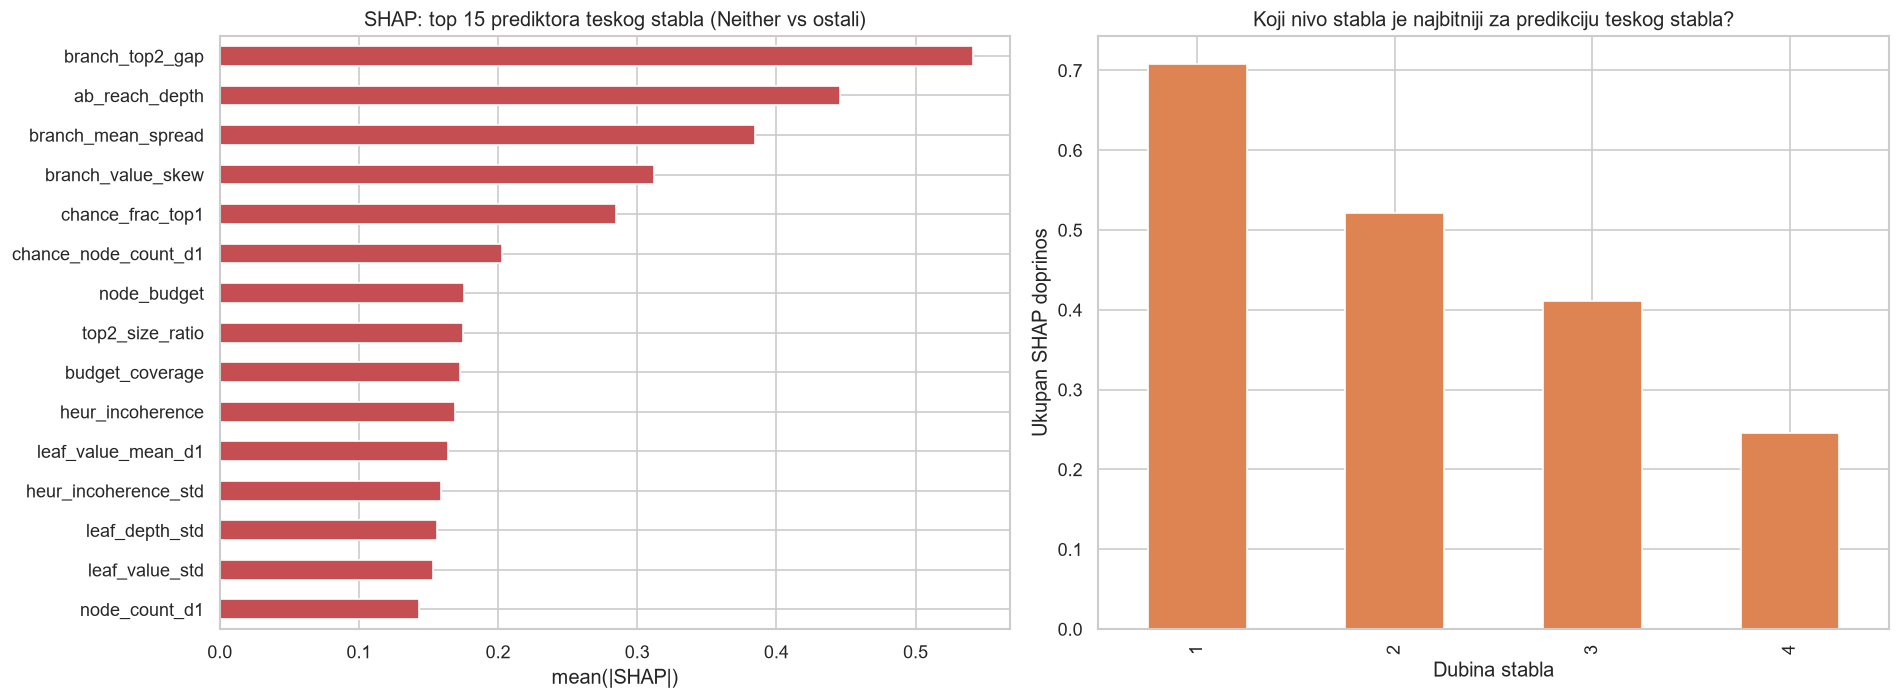

Top 10 prediktora tezine stabla:
branch_top2_gap         0.5409
ab_reach_depth          0.4459
branch_mean_spread      0.3847
branch_value_skew       0.3122
chance_frac_top1        0.2849
chance_node_count_d1    0.2029
node_budget             0.1754
top2_size_ratio         0.1744
budget_coverage         0.1725
heur_incoherence        0.1692


In [ ]:
import re

is_neither = (df["which_algo"] == "Neither").astype(int)
n_hard = is_neither.sum()
n_easy = (is_neither == 0).sum()

X_B_df = pd.DataFrame(X_B, columns=feat_B)

xgb_hard = XGBClassifier(
    n_estimators=300, random_state=42, verbosity=0, eval_metric="logloss",
    scale_pos_weight=n_easy / n_hard
)
xgb_hard.fit(X_B_df, is_neither)

shap_mat = xgb_hard.get_booster().predict(
    xgb.DMatrix(X_B_df, feature_names=feat_B), pred_contribs=True
)
shap_vals = shap_mat[:, :-1]

mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=feat_B).sort_values(ascending=False)

depth_shap = {}
for d in range(1, 5):  
    depth_cols = [c for c in feat_B if re.search(rf'_d{d}$', c)]
    if not depth_cols:
        continue
    col_idxs = [feat_B.index(c) for c in depth_cols]
    depth_shap[d] = np.abs(shap_vals[:, col_idxs]).sum(axis=1).mean()

depth_series = pd.Series(depth_shap)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mean_abs_shap.head(15).sort_values().plot.barh(ax=axes[0], color=NEG_COLOR)
axes[0].set_title("SHAP: top 15 prediktora teskog stabla (Neither vs ostali)")
axes[0].set_xlabel("mean(|SHAP|)")

depth_series.plot.bar(ax=axes[1], color=MED_COLOR)
axes[1].set_xlabel("Dubina stabla")
axes[1].set_ylabel("Ukupan SHAP doprinos")
axes[1].set_title("Koji nivo stabla je najbitniji za predikciju teskog stabla?")

plt.tight_layout()
plt.savefig("../plots/visualizations/06_hard_tree_shap.png", dpi=120)
plt.show()

print("Top 10 prediktora tezine stabla:")
print(mean_abs_shap.head(10).round(4).to_string())